# Predicción de Abandono Escolar y Éxito Académico
## Modelo: Red Neuronal Artificial (ANN)
**Dataset:** Predict Students' Dropout and Academic Success — UCI ML Repository (ID 697)

In [1]:
import pandas as pd

In [2]:
students = pd.read_csv('students.csv')

In [3]:
students.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
# Ver cuántas filas y columnas tiene el dataset
students.shape

(4424, 37)

In [5]:
# Eliminar filas con valores nulos
students = students.dropna()
students.shape

(4424, 37)

In [6]:
# Separar variables de entrada (X) y variable objetivo (y)
# Target: Dropout=0, Enrolled=1, Graduate=2
from sklearn.preprocessing import LabelEncoder
import pickle

CLASS_NAMES = ['Dropout', 'Enrolled', 'Graduate']
X = students.drop('Target', axis=1)
le = LabelEncoder()
le.fit(CLASS_NAMES)  # Orden fijo
y = le.transform(students['Target'])

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('LabelEncoder guardado')

LabelEncoder guardado


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [8]:
# StandardScaler: normaliza los datos para que todas las columnas
# tengan la misma escala. Esto es importante para la Red Neuronal
# porque si una columna tiene valores muy grandes y otra muy pequeños,
# la red no aprende bien.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # ajusta y transforma el train
X_test_sc  = scaler.transform(X_test)       # solo transforma el test

# Guardar el scaler (lo necesita app.py para normalizar datos nuevos)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Scaler guardado')

Scaler guardado


In [9]:
# Red Neuronal Artificial con 3 capas ocultas: 128, 64 y 32 neuronas
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
ann.fit(X_train_sc, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [10]:
y_pred = ann.predict(X_test_sc)

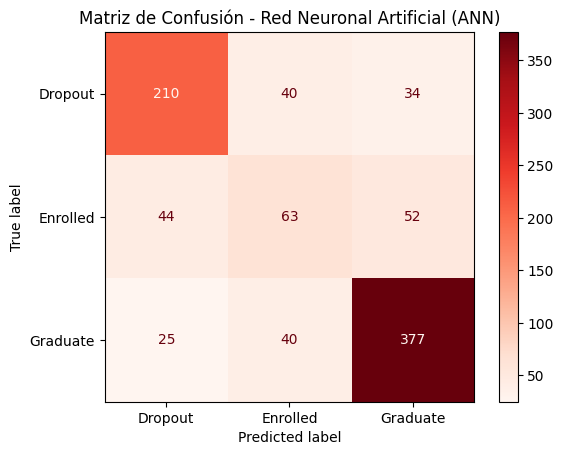

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=CLASS_NAMES)
disp.plot(cmap='Reds')
plt.title('Matriz de Confusión - Red Neuronal Artificial (ANN)')
plt.show()

In [12]:
from sklearn.metrics import accuracy_score, classification_report

print('Accuracy:', accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Accuracy: 0.7344632768361582

              precision    recall  f1-score   support

     Dropout       0.75      0.74      0.75       284
    Enrolled       0.44      0.40      0.42       159
    Graduate       0.81      0.85      0.83       442

    accuracy                           0.73       885
   macro avg       0.67      0.66      0.67       885
weighted avg       0.73      0.73      0.73       885



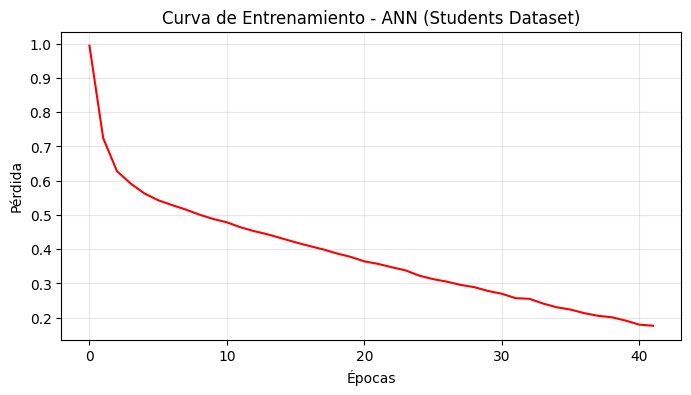

In [13]:
# Curva de pérdida durante el entrenamiento
plt.figure(figsize=(8, 4))
plt.plot(ann.loss_curve_, color='red')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curva de Entrenamiento - ANN (Students Dataset)')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Guardar el modelo ANN entrenado para usarlo en app.py
with open('ann_model.pkl', 'wb') as f:
    pickle.dump(ann, f)

print('Modelo ANN guardado como ann_model.pkl')

Modelo ANN guardado como ann_model.pkl
